In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import StackingClassifier

from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

In [40]:
data = pd.read_csv("train.csv")

In [41]:
data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [42]:
data.columns.tolist()

['battery_power',
 'blue',
 'clock_speed',
 'dual_sim',
 'fc',
 'four_g',
 'int_memory',
 'm_dep',
 'mobile_wt',
 'n_cores',
 'pc',
 'px_height',
 'px_width',
 'ram',
 'sc_h',
 'sc_w',
 'talk_time',
 'three_g',
 'touch_screen',
 'wifi',
 'price_range']

In [43]:
data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [45]:
data.shape

(2000, 21)

In [46]:
data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [47]:
data.duplicated().sum()

0

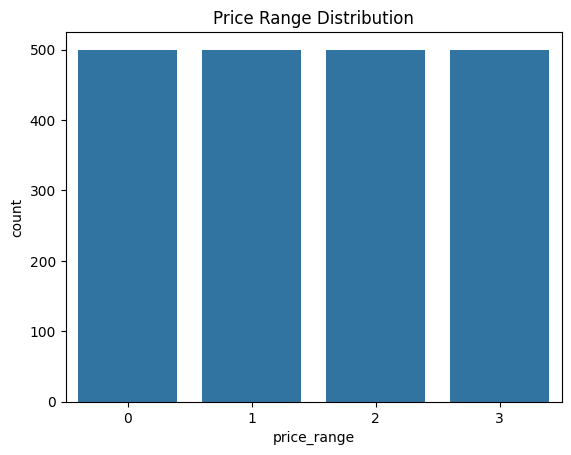

In [48]:
sns.countplot(
    x='price_range',
    data=data
)

plt.title(
    "Price Range Distribution"
)

plt.show()

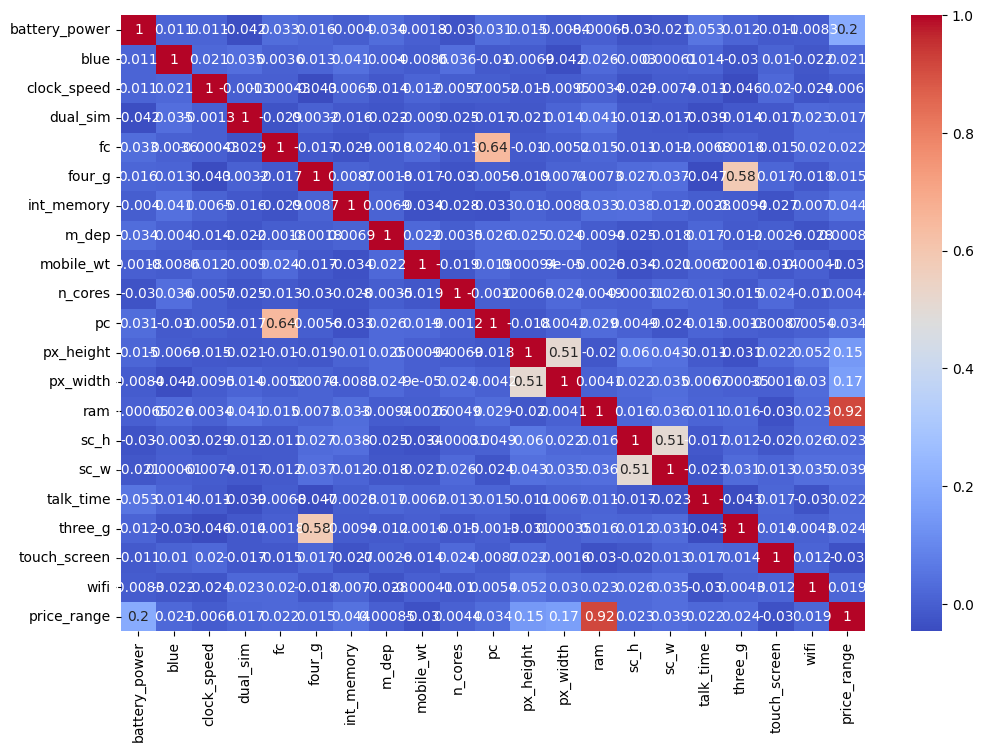

In [50]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    cmap='coolwarm',
    annot=True
)

plt.show()

In [74]:
features = [
    'battery_power',
    'ram',
    'px_height',
    'px_width',
    'mobile_wt',
    'n_cores'
]

X = data[features]

y = data['price_range']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
lr = LogisticRegression(
    max_iter=5000
)

dt = DecisionTreeClassifier(
    random_state=42
)

rf = RandomForestClassifier(
    random_state=42
)

In [77]:
lr.fit(X_train, y_train)

c:\Users\Chinnu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [78]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [79]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [80]:
lr_pred = lr.predict(X_test)

In [81]:
dt_pred = dt.predict(X_test)

In [82]:
rf_pred = rf.predict(X_test)

In [83]:
lr_score = accuracy_score(y_test, lr_pred)

dt_score = accuracy_score(y_test, dt_pred)

rf_score = accuracy_score(y_test, rf_pred)

print("Logistic Regression:", lr_score)

print("Decision Tree:", dt_score)

print("Random Forest:", rf_score)

Logistic Regression: 0.8875
Decision Tree: 0.84
Random Forest: 0.935


In [84]:
stack_model = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('rf', rf)
    ],
    final_estimator=LogisticRegression()
)

In [85]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [86]:
stack_model.fit(
    X_train,
    y_train
)

c:\Users\Chinnu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Chinnu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/

StackingClassifier(estimators=[('lr', LogisticRegression(max_iter=5000)),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [87]:
stack_pred = stack_model.predict(
    X_test
)

In [88]:
stack_score = accuracy_score(
    y_test,
    stack_pred
)

print(
    "Stacking Classifier:",
    stack_score
)

Stacking Classifier: 0.9075


In [89]:
cm = confusion_matrix(
    y_test,
    stack_pred
)

print(cm)

[[ 98   7   0   0]
 [  3  83   5   0]
 [  0   5  79   8]
 [  0   0   9 103]]


In [90]:
print(
    classification_report(
        y_test,
        stack_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       105
           1       0.87      0.91      0.89        91
           2       0.85      0.86      0.85        92
           3       0.93      0.92      0.92       112

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



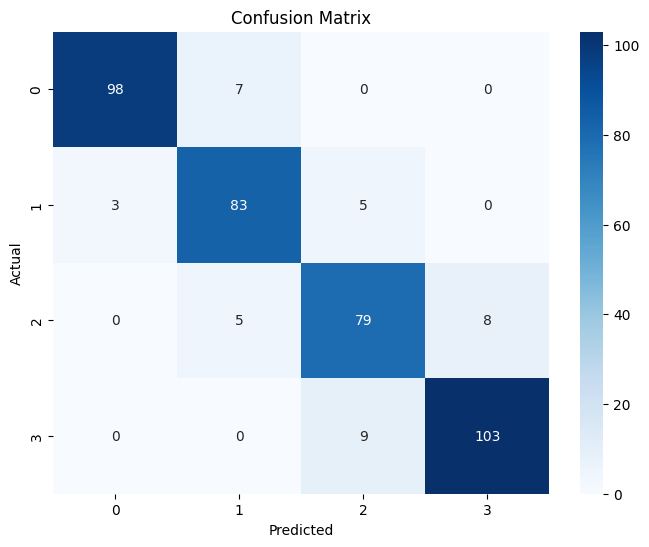

In [91]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

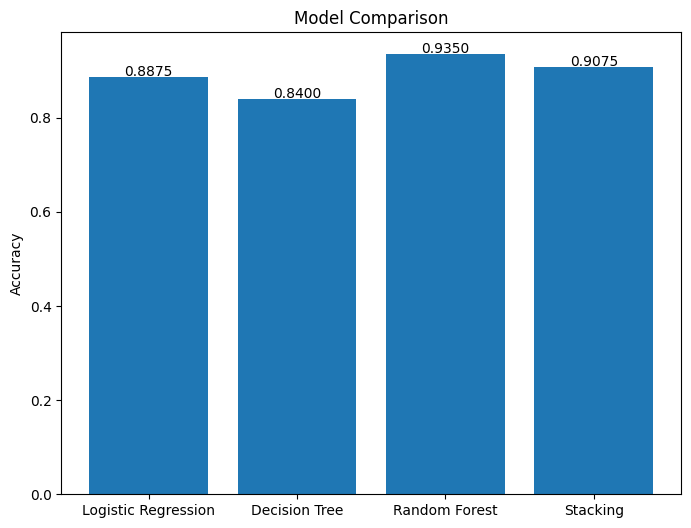

In [92]:
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Stacking"
]

scores = [
    lr_score,
    dt_score,
    rf_score,
    stack_score
]

plt.figure(figsize=(8,6))

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

for i, score in enumerate(scores):

    plt.text(
        i,
        score + 0.002,
        f"{score:.4f}",
        ha='center'
    )

plt.show()

In [93]:
print("Logistic Regression:", lr_score)
print("Decision Tree:", dt_score)
print("Random Forest:", rf_score)
print("Stacking Classifier:", stack_score)

Logistic Regression: 0.8875
Decision Tree: 0.84
Random Forest: 0.935
Stacking Classifier: 0.9075


In [94]:
import joblib

joblib.dump(stack_model, "stacking_classifier.pkl")

['stacking_classifier.pkl']